In [1]:
from sympy import *
import matplotlib.pyplot as plt
import numpy as np

In [2]:
from sympy.plotting import plot

# Q. 54

## (a)

In [3]:
x, y = symbols('x, y')
C = symbols('C')

In [4]:
eq = Eq(integrate(3*y**2 + 1, y) - integrate(-8*x - 5, x), C)
eq

Eq(4*x**2 + 5*x + y**3 + y, C)

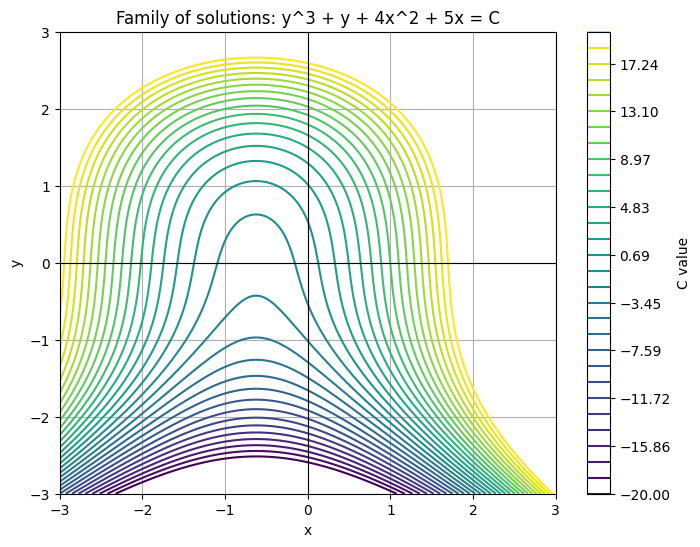

In [5]:
# plotting
x_val = np.linspace(-3, 3, 500)
y_val = np.linspace(-3, 3, 500)
X, Y = np.meshgrid(x_val, y_val)

F = 4*X**2 + 5*X + Y**3 + Y
C_vals = np.linspace(-20, 20, 30)

plt.figure(figsize=(8,6))
contours = plt.contour(X, Y, F, levels = C_vals, cmap='viridis')
plt.colorbar(contours, label='C value')
plt.title("Family of solutions: y^3 + y + 4x^2 + 5x = C")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)
plt.show()

## (b)

In [6]:
values = [(0, -1), (0, 2), (-1, 4), (-1, -3)]
F_expr = integrate(3*y**2 + 1, y) - integrate(-8*x - 5, x)
C_vals = [F_expr.subs({x: val[0], y:val[1]}) for val in values]
C_vals

[-2, 10, 67, -31]

In [7]:
C_vals.sort()
C_vals

[-31, -2, 10, 67]

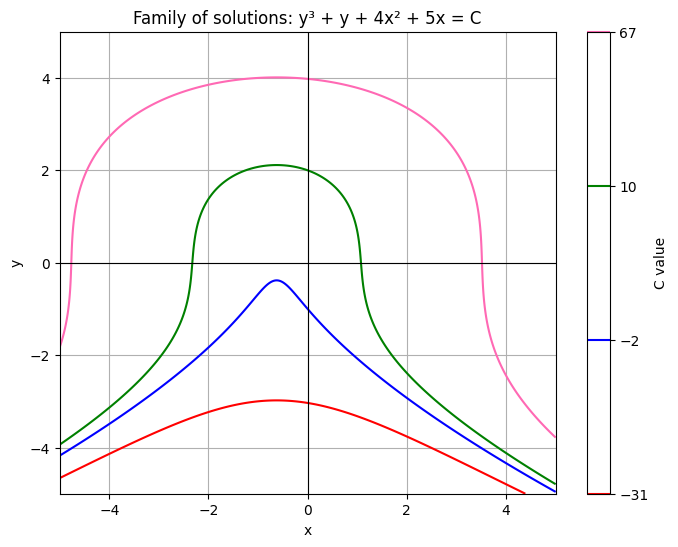

In [8]:
x_val = np.linspace(-5, 5, 500)
y_val = np.linspace(-5, 5, 500)
X, Y = np.meshgrid(x_val, y_val)

F = 4*X**2 + 5*X + Y**3 + Y

colors = ["red", "blue", "green", "hotpink"]
plt.figure(figsize=(8, 6))
contours = plt.contour(X, Y, F, levels = C_vals, colors=colors)
plt.colorbar(contours, label='C value')
plt.title("Family of solutions: y³ + y + 4x² + 5x = C")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)
plt.show()

# Q. 55

## (a)

In [9]:
x = symbols('x')
y = symbols('y', cls=Function)
expr = integrate(2*y(x) + 2, y(x)) - integrate(4*x**3+6*x, x)
eq = Eq(expr, C)
eq

Eq(-x**4 - 3*x**2 + y(x)**2 + 2*y(x), C)

In [10]:
particular_sol = eq.subs({C : expr.subs({x:0, y(x):-3})})
particular_sol

Eq(-x**4 - 3*x**2 + y(x)**2 + 2*y(x), 3)

## (b)

In [11]:
eq = (2*y(x) + 2)*y(x).diff(x) - (4*x**3+6*x)
dsolve(eq, ics={y(0):-3})

Eq(y(x), -sqrt(x**4 + 3*x**2 + 4) - 1)

## (c)

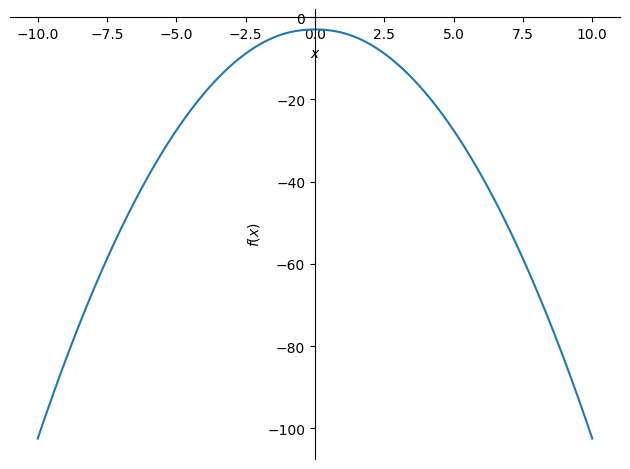

In [12]:
x = symbols('x')
y = -1 - (x**4 + 3*x**2 + 4)**0.5

plot(y)

## (d)

[]


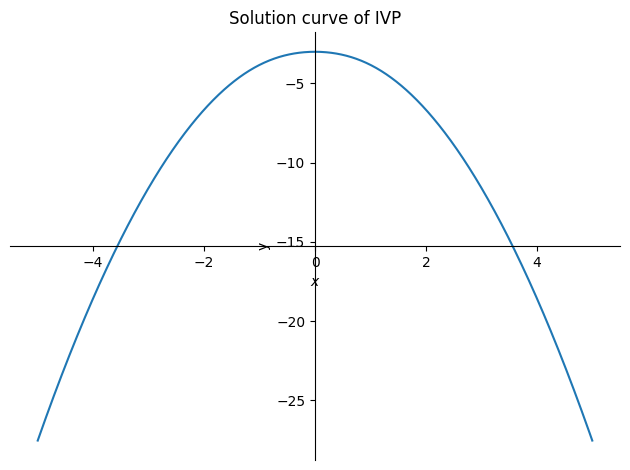

In [13]:
x = symbols('x', real=True)
y = -1 - sqrt(x**4 + 3*x**2 + 4)

print(solve(y + 1, x))  # Should return []

plot(y, (x, -5, 5), ylabel='y', title='Solution curve of IVP')

so (-inf, inf) is the domain of the solution

# Q.56

## (a)

In [14]:
x = symbols('x')
y = symbols('y', cls=Function)
C = symbols('C')
eq = Eq(y(x).diff(x), x*(1-x)/(y(x)*(-2+y(x))))
eq

Eq(Derivative(y(x), x), x*(1 - x)/((y(x) - 2)*y(x)))

In [15]:
soln = Eq(integrate(y(x)*(-2+y(x)), y(x)), integrate(x*(1-x), x) + C) 
soln

Eq(y(x)**3/3 - y(x)**2, C - x**3/3 + x**2/2)

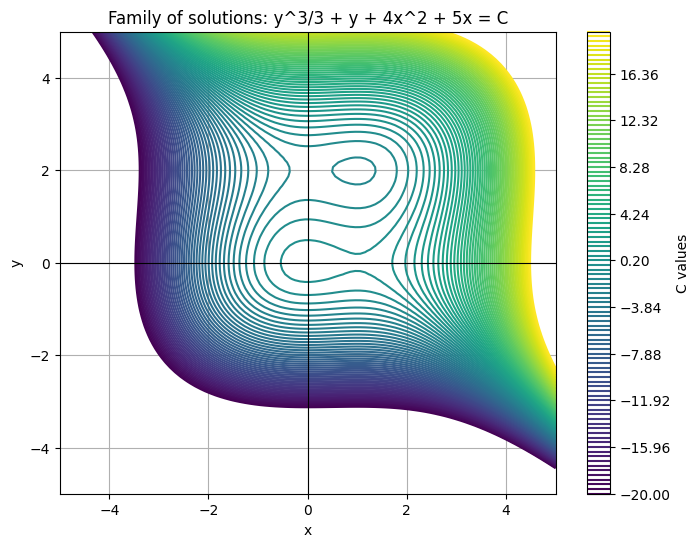

In [16]:
x_val = np.linspace(-5, 5, 100)
y_val = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(x_val, y_val)

F = Y**3/3 - Y**2 + X**3/3 - X**2/2
C_vals = np.linspace(-20, 20, 100)

plt.figure(figsize=(8, 6))
contours = plt.contour(X, Y, F, levels = C_vals, cmap='viridis')
plt.colorbar(contours, label='C values')
plt.title("Family of solutions: y^3/3 + y + 4x^2 + 5x = C")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)
plt.show()

## (b)

In [17]:
solve(soln.subs({x:0, y(x):3/2}), C)

[-1.12500000000000]

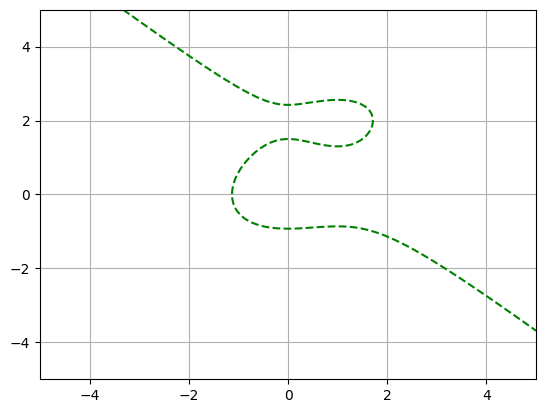

In [18]:
contours = plt.contour(X, Y, F, levels = [-1.125], colors=['green'])
plt.grid(True)

In [27]:
# For interval of definition :
# finding where the tangents are vertical => dy/dx = inf
# => y = 0 or y = 2
# Now solving for all the points where the tangents are vertical

y = symbols('y') 
implicit = Eq(y**3/3 - y**2, x**2/2 - x**3/3 + C)
solve(implicit.subs([(y, 0), (C, -1.125)]))

x0 = solve(implicit.subs([(C, -1.125), (y, 0)]), x)
x2 = solve(implicit.subs([(C, -1.125), (y, 2)]), x)

print(x0)
print(x2)

x0_real = [val.evalf() for val in x0 if val.is_real]
x2_real = [val.evalf() for val in x2 if val.is_real]

print('\n')
print("x where y=0:", x0_real)
print("x where y=2:", x2_real)

[-1.13231649937004, 1.31615824968502 - 1.11729264992962*I, 1.31615824968502 + 1.11729264992962*I]
[1.71299437868081, -0.106497189340406 - 0.594572554053275*I, -0.106497189340406 + 0.594572554053275*I]


x where y=0: [-1.13231649937004]
x where y=2: [1.71299437868081]


Since x = 0 lie inside the interval the largest interval is approx (-1.1323, 1.7129)

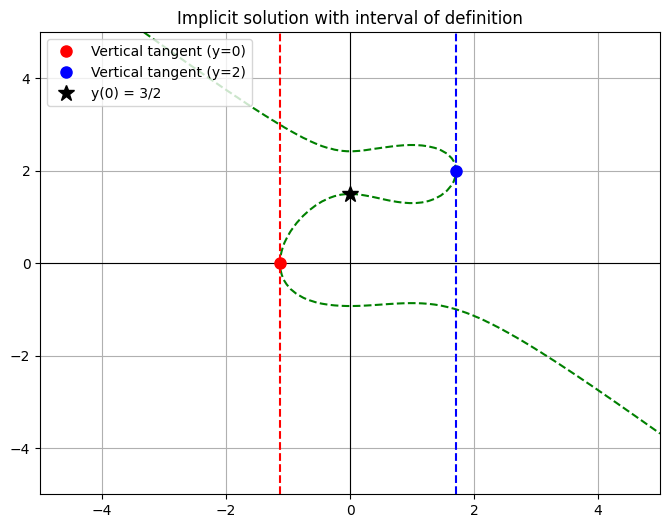

In [39]:
fig, ax = plt.subplots(figsize=(8, 6))

contours = ax.contour(X, Y, F, levels=[-1.125], colors=['green'])
ax.axhline(0, color='black', linewidth=0.8)
ax.axvline(0, color='black', linewidth=0.8)

# Mark the vertical tangent points and lines
ax.plot(-1.132, 0, 'ro', markersize=8, label='Vertical tangent (y=0)')
ax.plot(1.713, 2, 'bo', markersize=8, label='Vertical tangent (y=2)')
ax.axvline(-1.132, color='r', linestyle='--')
ax.axvline(1.713, color='b', linestyle='--')

# Mark initial condition
ax.plot(0, 1.5, 'k*', markersize=12, label='y(0) = 3/2')

ax.set_xlim(-5, 5)
ax.set_ylim(-5, 5)
ax.legend()
ax.grid(True)
ax.set_title("Implicit solution with interval of definition")
plt.show()

In [40]:
ax.legend?

Signature: ax.legend(*args, **kwargs)
Docstring:
Place a legend on the Axes.

Call signatures::

    legend()
    legend(handles, labels)
    legend(handles=handles)
    legend(labels)

The call signatures correspond to the following different ways to use
this method:

**1. Automatic detection of elements to be shown in the legend**

The elements to be added to the legend are automatically determined,
when you do not pass in any extra arguments.

In this case, the labels are taken from the artist. You can specify
them either at artist creation or by calling the
:meth:`~.Artist.set_label` method on the artist::

    ax.plot([1, 2, 3], label='Inline label')
    ax.legend()

or::

    line, = ax.plot([1, 2, 3])
    line.set_label('Label via method')
    ax.legend()

.. note::
    Specific artists can be excluded from the automatic legend element
    selection by using a label starting with an underscore, "_".
    A string starting with an underscore is the default label for all
    artist